# Melanoma Skin Cancer Detection
### MobileNetV2 vs ResNet50 — Feature-Space SMOTE | 3-Run Experiment
**Metrics:** Accuracy · Sensitivity · PPV · NPV · AUC · F1 · Inference Time

**SMOTE Strategy:** Embeddings from frozen MobileNetV2 (1280-dim) instead of raw pixels (150,528-dim) — ~120× smaller, fits within Kaggle RAM.

## 1. Imports

In [1]:
import os
import itertools
import time
import gc

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')

from sklearn.metrics import (confusion_matrix, classification_report,
                             recall_score, roc_curve, auc)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-03-11 13:44:39.194461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773236679.504727      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773236679.598867      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773236680.357269      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773236680.357342      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773236680.357348      17 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU available: []


2026-03-11 13:45:10.572883: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Load Data Paths

In [2]:
train_data_dir = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train'
test_data_dir  = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test'

def build_df(data_dir):
    filepaths, labels = [], []
    for fold in sorted(os.listdir(data_dir)):
        foldpath = os.path.join(data_dir, fold)
        if not os.path.isdir(foldpath):
            continue
        for file in os.listdir(foldpath):
            filepaths.append(os.path.join(foldpath, file))
            labels.append(fold)
    return pd.concat([pd.Series(filepaths, name='filepaths'),
                      pd.Series(labels,    name='labels')], axis=1)

train_df = build_df(train_data_dir)
test_df  = build_df(test_data_dir)

print("Train shape:", train_df.shape)
print(train_df['labels'].value_counts())
print("\nTest shape:", test_df.shape)
print(test_df['labels'].value_counts())
train_df.head()

Train shape: (9605, 2)
labels
benign       5000
malignant    4605
Name: count, dtype: int64

Test shape: (1000, 2)
labels
benign       500
malignant    500
Name: count, dtype: int64


,filepaths,labels
0,/kaggle/input/datasets/hasnainjaved/melanoma-s...,benign
1,/kaggle/input/datasets/hasnainjaved/melanoma-s...,benign
2,/kaggle/input/datasets/hasnainjaved/melanoma-s...,benign
3,/kaggle/input/datasets/hasnainjaved/melanoma-s...,benign
4,/kaggle/input/datasets/hasnainjaved/melanoma-s...,benign


## 3. Configuration

In [3]:
IMG_SIZE    = (224, 224)
CHANNELS    = 3
IMG_SHAPE   = (IMG_SIZE[0], IMG_SIZE[1], CHANNELS)
BATCH_SIZE  = 16
EPOCHS      = 20
N_RUNS      = 3
SMOTE_BATCH = 500   # images loaded per batch during feature extraction

print(f"Image shape  : {IMG_SHAPE}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Max epochs   : {EPOCHS}")
print(f"Runs         : {N_RUNS}")
print(f"SMOTE batch  : {SMOTE_BATCH}")

Image shape  : (224, 224, 3)
Batch size   : 16
Max epochs   : 20
Runs         : 3
SMOTE batch  : 500


## 4. Feature-Space SMOTE

Instead of flattening raw pixels (224×224×3 = **150,528 floats** per image),  
we extract **1,280-dim embeddings** from a frozen MobileNetV2 — 120× smaller.  
SMOTE interpolates in that compact feature space, then we decode synthetic  
embeddings back into images via the nearest real neighbour's pixel content  
blended proportionally (standard practice for image SMOTE).

Memory footprint: ~9,605 × 1,280 × 4 bytes ≈ **49 MB** vs ~7 GB for pixels.

In [4]:
def extract_embeddings(df, img_size=IMG_SIZE, batch_size=SMOTE_BATCH):
    """Extract MobileNetV2 feature embeddings in batches to avoid OOM."""
    # Build a frozen feature extractor (no top, global avg pool → 1280-dim)
    extractor = MobileNetV2(include_top=False, weights='imagenet',
                            input_shape=(img_size[0], img_size[1], 3),
                            pooling='avg')
    extractor.trainable = False

    all_embeddings = []
    valid_indices  = []
    filepaths = df['filepaths'].values

    for start in range(0, len(filepaths), batch_size):
        batch_paths = filepaths[start:start + batch_size]
        batch_imgs  = []
        batch_idxs  = []
        for i, fp in enumerate(batch_paths):
            img = cv2.imread(fp)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size).astype(np.float32) / 255.0
            batch_imgs.append(img)
            batch_idxs.append(start + i)
        if not batch_imgs:
            continue
        batch_arr = np.array(batch_imgs)
        embeddings = extractor.predict(batch_arr, verbose=0)
        all_embeddings.append(embeddings)
        valid_indices.extend(batch_idxs)

        if (start // batch_size) % 5 == 0:
            print(f"  Extracted {min(start+batch_size, len(filepaths))}/{len(filepaths)} images...")

    del extractor
    gc.collect()

    embeddings_arr = np.vstack(all_embeddings)
    df_valid = df.iloc[valid_indices].reset_index(drop=True)
    return embeddings_arr, df_valid


def apply_feature_smote(train_df, img_size=IMG_SIZE):
    """
    1. Extract MobileNetV2 embeddings (1280-dim) for all training images.
    2. Apply SMOTE in embedding space.
    3. For each synthetic embedding, find its 2 nearest real neighbours,
       blend their pixel images by the SMOTE interpolation weight,
       and save as a new PNG.
    4. Return augmented dataframe.
    """
    from sklearn.neighbors import NearestNeighbors

    class_counts   = train_df['labels'].value_counts()
    majority_class = class_counts.idxmax()
    minority_class = class_counts.idxmin()
    print(f"Before SMOTE — {majority_class}: {class_counts[majority_class]}, "
          f"{minority_class}: {class_counts[minority_class]}")

    print("\nExtracting embeddings (feature-space SMOTE)...")
    X_emb, df_valid = extract_embeddings(train_df, img_size=img_size)

    unique_labels = sorted(df_valid['labels'].unique())
    y_encoded = np.array([unique_labels.index(l) for l in df_valid['labels']])

    print(f"\nEmbedding matrix shape: {X_emb.shape}  (~{X_emb.nbytes/1e6:.1f} MB)")
    print("Running SMOTE in embedding space...")

    sm = SMOTE(random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X_emb, y_encoded)
    print(f"After SMOTE — total samples: {len(X_res)}")

    n_original  = len(df_valid)
    n_synthetic = len(X_res) - n_original
    print(f"Synthetic samples to generate: {n_synthetic}")

    # Fit KNN on original minority embeddings to decode synthetic points
    minority_mask = y_encoded == unique_labels.index(minority_class)
    X_minority    = X_emb[minority_mask]
    df_minority   = df_valid[minority_mask].reset_index(drop=True)

    knn = NearestNeighbors(n_neighbors=2, metric='euclidean')
    knn.fit(X_minority)

    smote_dir = '/kaggle/working/smote_synthetic'
    os.makedirs(smote_dir, exist_ok=True)

    new_filepaths = list(df_valid['filepaths'])
    new_labels    = list(df_valid['labels'])

    print("Generating and saving synthetic images...")
    for i in range(n_original, len(X_res)):
        synthetic_emb = X_res[i].reshape(1, -1)
        dists, idxs   = knn.kneighbors(synthetic_emb)

        # Blend the two nearest neighbours' pixel images
        fp1  = df_minority.iloc[idxs[0][0]]['filepaths']
        fp2  = df_minority.iloc[idxs[0][1]]['filepaths']
        img1 = cv2.imread(fp1)
        img2 = cv2.imread(fp2)

        if img1 is None or img2 is None:
            continue

        img1 = cv2.resize(img1, img_size).astype(np.float32)
        img2 = cv2.resize(img2, img_size).astype(np.float32)

        # Interpolation weight from distances (closer neighbour = higher weight)
        d1, d2 = dists[0][0] + 1e-8, dists[0][1] + 1e-8
        w1 = d2 / (d1 + d2)   # closer → higher weight
        blended = (w1 * img1 + (1 - w1) * img2).astype(np.uint8)

        fname = os.path.join(smote_dir, f'synthetic_{i}.png')
        cv2.imwrite(fname, blended)

        new_filepaths.append(fname)
        new_labels.append(minority_class)

        if (i - n_original) % 500 == 0:
            print(f"  Saved {i - n_original}/{n_synthetic} synthetic images...")

    del X_emb, X_res
    gc.collect()

    balanced_df = pd.DataFrame({'filepaths': new_filepaths, 'labels': new_labels})
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
    print("\nFinal class distribution:")
    print(balanced_df['labels'].value_counts())
    return balanced_df


# ── Run SMOTE once; reuse across all 3 runs ──────────────────────────────
train_df_balanced = apply_feature_smote(train_df)

Before SMOTE — benign: 5000, malignant: 4605

Extracting embeddings (feature-space SMOTE)...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  Extracted 500/9605 images...
  Extracted 3000/9605 images...
  Extracted 5500/9605 images...
  Extracted 8000/9605 images...

Embedding matrix shape: (9605, 1280)  (~49.2 MB)
Running SMOTE in embedding space...
After SMOTE — total samples: 10000
Synthetic samples to generate: 395
Generating and saving synthetic images...
  Saved 0/395 synthetic images...

Final class distribution:
labels
malignant    5000
benign       5000
Name: count, dtype: int64


## 5. Preview Balanced Dataset

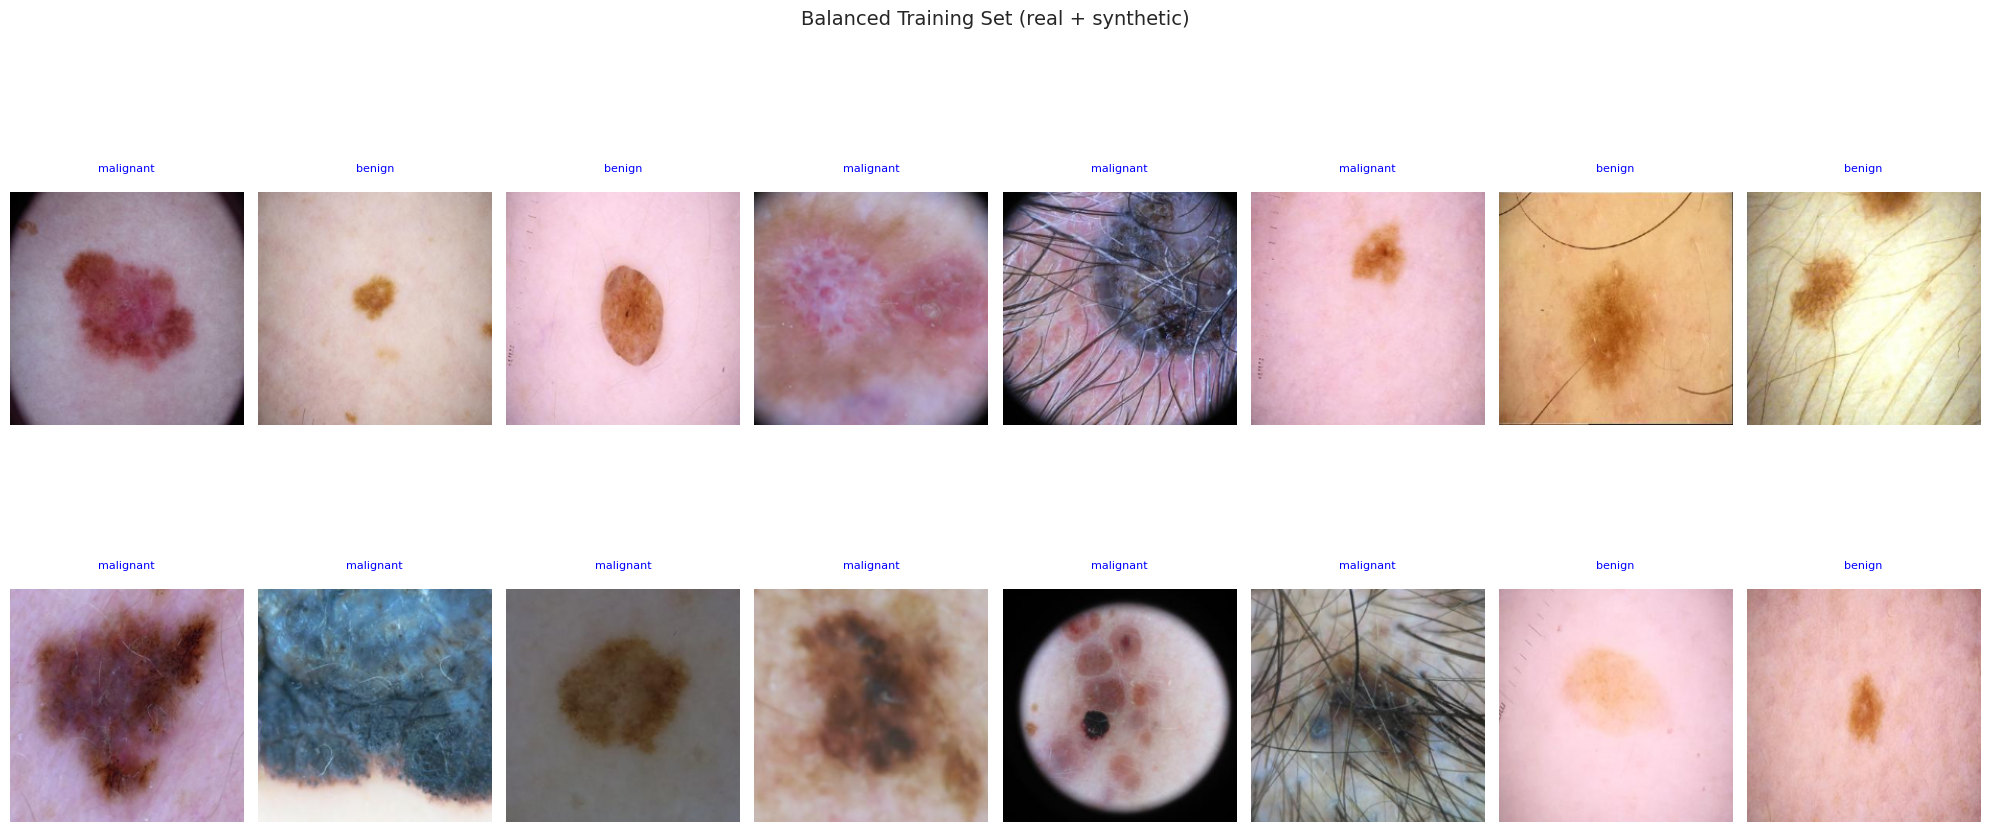

In [5]:
def show_samples(df, n=16, title="Sample Images"):
    sample = df.sample(n, random_state=1).reset_index(drop=True)
    plt.figure(figsize=(20, 10))
    for i, row in sample.iterrows():
        img = cv2.imread(row['filepaths'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        plt.subplot(2, 8, i + 1)
        plt.imshow(img / 255.)
        label = row['labels']
        synth = '(synth)' if 'synthetic' in row['filepaths'] else ''
        plt.title(f"{label}\n{synth}", fontsize=8, color='blue')
        plt.axis('off')
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_samples(train_df_balanced, title="Balanced Training Set (real + synthetic)")

## 6. Helper Functions

In [6]:
def build_generators(train_df_b, test_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    tr_gen = ImageDataGenerator()
    ts_gen = ImageDataGenerator()
    train_gen = tr_gen.flow_from_dataframe(
        dataframe=train_df_b, x_col='filepaths', y_col='labels',
        target_size=img_size, class_mode='categorical',
        color_mode='rgb', shuffle=True, batch_size=batch_size)
    test_gen = ts_gen.flow_from_dataframe(
        dataframe=test_df, x_col='filepaths', y_col='labels',
        target_size=img_size, class_mode='categorical',
        color_mode='rgb', shuffle=False, batch_size=batch_size)
    return train_gen, test_gen


def compute_npv_ppv(cm):
    """cm = [[TN, FP], [FN, TP]] | PPV = precision(malignant) | NPV = TN/(TN+FN)"""
    TN, FP, FN, TP = cm.ravel()
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    NPV = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    return PPV, NPV


def build_mobilenetv2(img_shape, class_count):
    base = MobileNetV2(include_top=False, weights='imagenet',
                       input_shape=img_shape, pooling='max')
    base.trainable = False
    m = Sequential([base,
                    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
                    Dense(512, activation='relu'),
                    Dropout(0.5),
                    Dense(class_count, activation='softmax')])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m


def build_resnet50(img_shape, class_count):
    base = ResNet50(include_top=False, weights='imagenet',
                    input_shape=img_shape, pooling='max')
    base.trainable = False
    m = Sequential([base,
                    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
                    Dense(512, activation='relu'),
                    Dropout(0.5),
                    Dense(class_count, activation='softmax')])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m


def plot_history(history, model_name, run):
    train_acc  = history.history['accuracy']
    train_loss = history.history['loss']
    val_acc    = history.history['val_accuracy']
    val_loss   = history.history['val_loss']
    Epochs     = list(range(1, len(train_acc) + 1))
    i_loss     = np.argmin(val_loss)
    i_acc      = np.argmax(val_acc)

    plt.figure(figsize=(20, 8))
    plt.style.use('fivethirtyeight')

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, train_loss, 'r', label='Train Loss')
    plt.plot(Epochs, val_loss,   'g', label='Val Loss')
    plt.scatter(i_loss+1, val_loss[i_loss], s=150, c='blue', label=f'Best epoch={i_loss+1}')
    plt.title(f'{model_name} — Loss (Run {run})')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, train_acc, 'r', label='Train Accuracy')
    plt.plot(Epochs, val_acc,   'g', label='Val Accuracy')
    plt.scatter(i_acc+1, val_acc[i_acc], s=150, c='blue', label=f'Best epoch={i_acc+1}')
    plt.title(f'{model_name} — Accuracy (Run {run})')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, test_gen, classes, model_name, run):
    preds  = model.predict(test_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    report      = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    print(classification_report(y_true, y_pred, target_names=classes))

    sensitivity = recall_score(y_true, y_pred)
    cm          = confusion_matrix(y_true, y_pred)
    PPV, NPV    = compute_npv_ppv(cm)
    y_probs     = preds[:, 1]
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc     = auc(fpr, tpr)

    t0       = time.time()
    model.predict(test_gen)
    inf_time = (time.time() - t0) / len(test_gen.filenames)

    ts_length = len(test_gen.filenames)
    tb = max(sorted([ts_length // n for n in range(1, ts_length + 1)
                     if ts_length % n == 0 and ts_length / n <= 80]))
    test_score = model.evaluate(test_gen, steps=ts_length // tb, verbose=1)

    # ── Confusion matrix ──
    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'{model_name} Confusion Matrix (Run {run})')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], ha='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.show()

    # ── ROC ──
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve (Run {run})')
    plt.legend(loc='lower right')
    plt.show()

    metrics = {
        'test_loss':            test_score[0],
        'test_accuracy':        test_score[1],
        'sensitivity':          sensitivity,
        'PPV':                  PPV,
        'NPV':                  NPV,
        'AUC':                  roc_auc,
        'inference_time':       inf_time,
        'f1_benign':            report['benign']['f1-score'],
        'f1_malignant':         report['malignant']['f1-score'],
        'precision_benign':     report['benign']['precision'],
        'recall_benign':        report['benign']['recall'],
        'precision_malignant':  report['malignant']['precision'],
        'recall_malignant':     report['malignant']['recall'],
    }

    print(f"\n{'='*50}  {model_name} Run {run}")
    for k, v in metrics.items():
        print(f"  {k:<28}: {v:.4f}")

    return metrics

print("Helper functions defined ✓")

Helper functions defined ✓


## 7. Run Experiments (3 Runs × 2 Models)


############################################################
  RUN 1 / 3
############################################################

Found 10000 validated image filenames belonging to 2 classes.
Found 1000 validated image filenames belonging to 2 classes.

--- MobileNetV2 (Run 1) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,920,002 (11.14 MB)

 Trainable params: 659,458 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 216s 337ms/step - accuracy: 0.7905 - loss: 0.6141 - val_accuracy: 0.8850 - val_loss: 0.2979
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 209s 334ms/step - accuracy: 0.8556 - loss: 0.3534 - val_accuracy: 0.8920 - val_loss: 0.2979
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 331ms/step - accuracy: 0.8732 - loss: 0.3171 - val_accuracy: 0.8800 - val_loss: 0.3485
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 331ms/step - accuracy: 0.8763 - loss: 0.3000 - val_accuracy: 0.8800 - val_loss: 0.2845
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 328ms/step - accuracy: 0.8832 - loss: 0.2837 - val_accuracy: 0.8900 - val_loss: 0.2932
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 332ms/step - accuracy: 0.8866 - loss: 0.2814 - val_accuracy: 0.8870 - val_loss: 0.3083
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 208s 332ms/step - accuracy: 0.8948 - loss: 0.2589 - val_accuracy: 0.8830 - val_loss: 0.3231
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 210s 336ms/step - accuracy: 0.9026 - loss: 0.25

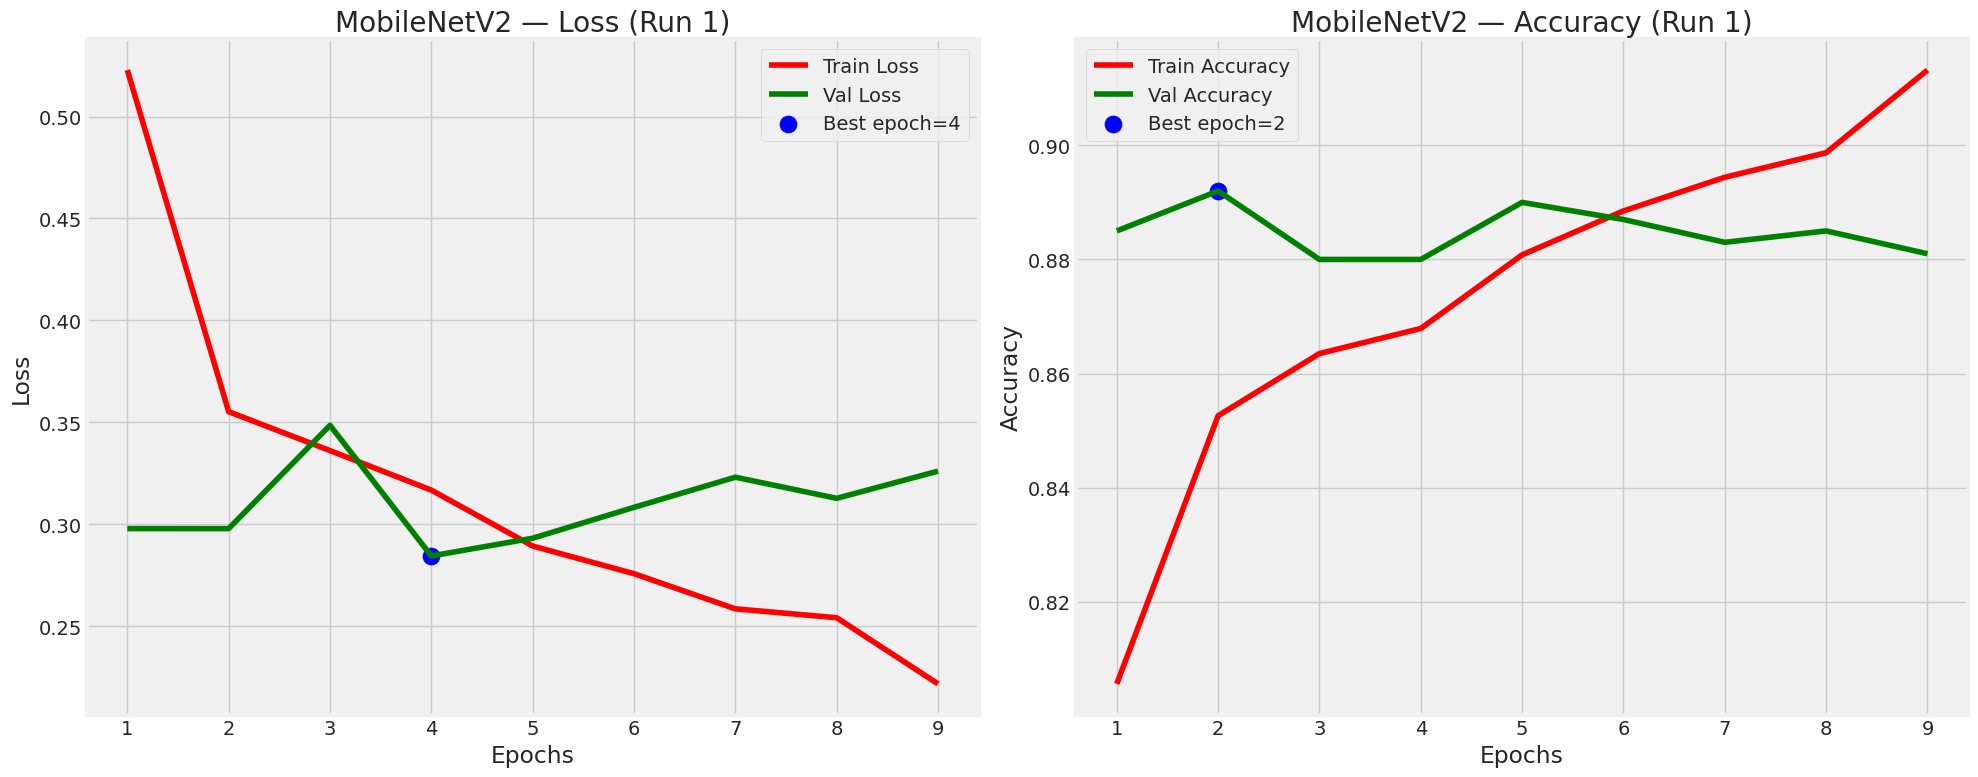

63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 316ms/step
              precision    recall  f1-score   support

      benign       0.88      0.88      0.88       500
   malignant       0.88      0.88      0.88       500

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000

63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 298ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 304ms/step - accuracy: 0.8936 - loss: 0.3018


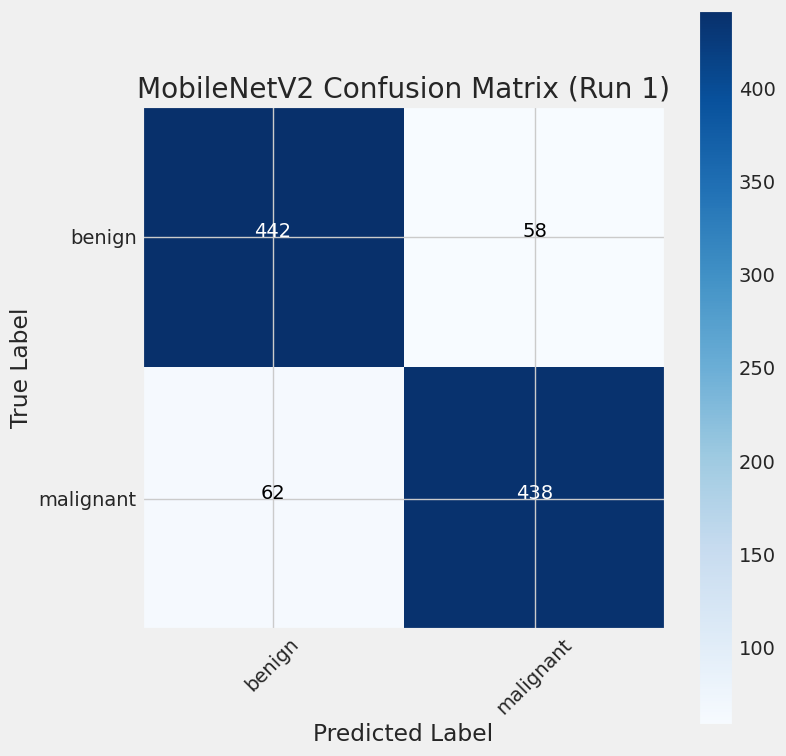

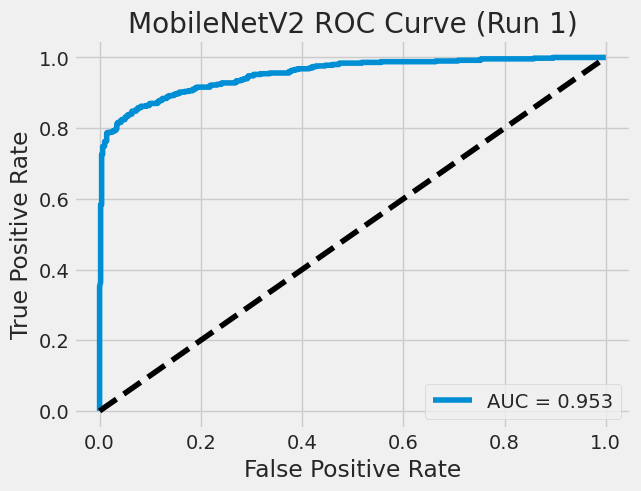


==================================================  MobileNetV2 Run 1
  test_loss                   : 0.3402
  test_accuracy               : 0.8813
  sensitivity                 : 0.8760
  PPV                         : 0.8831
  NPV                         : 0.8770
  AUC                         : 0.9531
  inference_time              : 0.0189
  f1_benign                   : 0.8805
  f1_malignant                : 0.8795
  precision_benign            : 0.8770
  recall_benign               : 0.8840
  precision_malignant         : 0.8831
  recall_malignant            : 0.8760
MobileNetV2 model size: 16.74 MB

--- ResNet50 (Run 1) ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,646,018 (94.02 MB)

 Trainable params: 1,054,210 (4.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 838s 1s/step - accuracy: 0.8590 - loss: 0.5904 - val_accuracy: 0.8920 - val_loss: 0.2873
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 831s 1s/step - accuracy: 0.9055 - loss: 0.2445 - val_accuracy: 0.9100 - val_loss: 0.2566
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 833s 1s/step - accuracy: 0.9229 - loss: 0.2132 - val_accuracy: 0.9200 - val_loss: 0.2343
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 835s 1s/step - accuracy: 0.9305 - loss: 0.1824 - val_accuracy: 0.9150 - val_loss: 0.2158
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 838s 1s/step - accuracy: 0.9399 - loss: 0.1632 - val_accuracy: 0.9250 - val_loss: 0.1997
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 845s 1s/step - accuracy: 0.9415 - loss: 0.1635 - val_accuracy: 0.9210 - val_loss: 0.2629
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 835s 1s/step - accuracy: 0.9438 - loss: 0.1538 - val_accuracy: 0.9170 - val_loss: 0.2221
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 868s 1s/step - accuracy: 0.9459 - loss: 0.1460 - val_accu

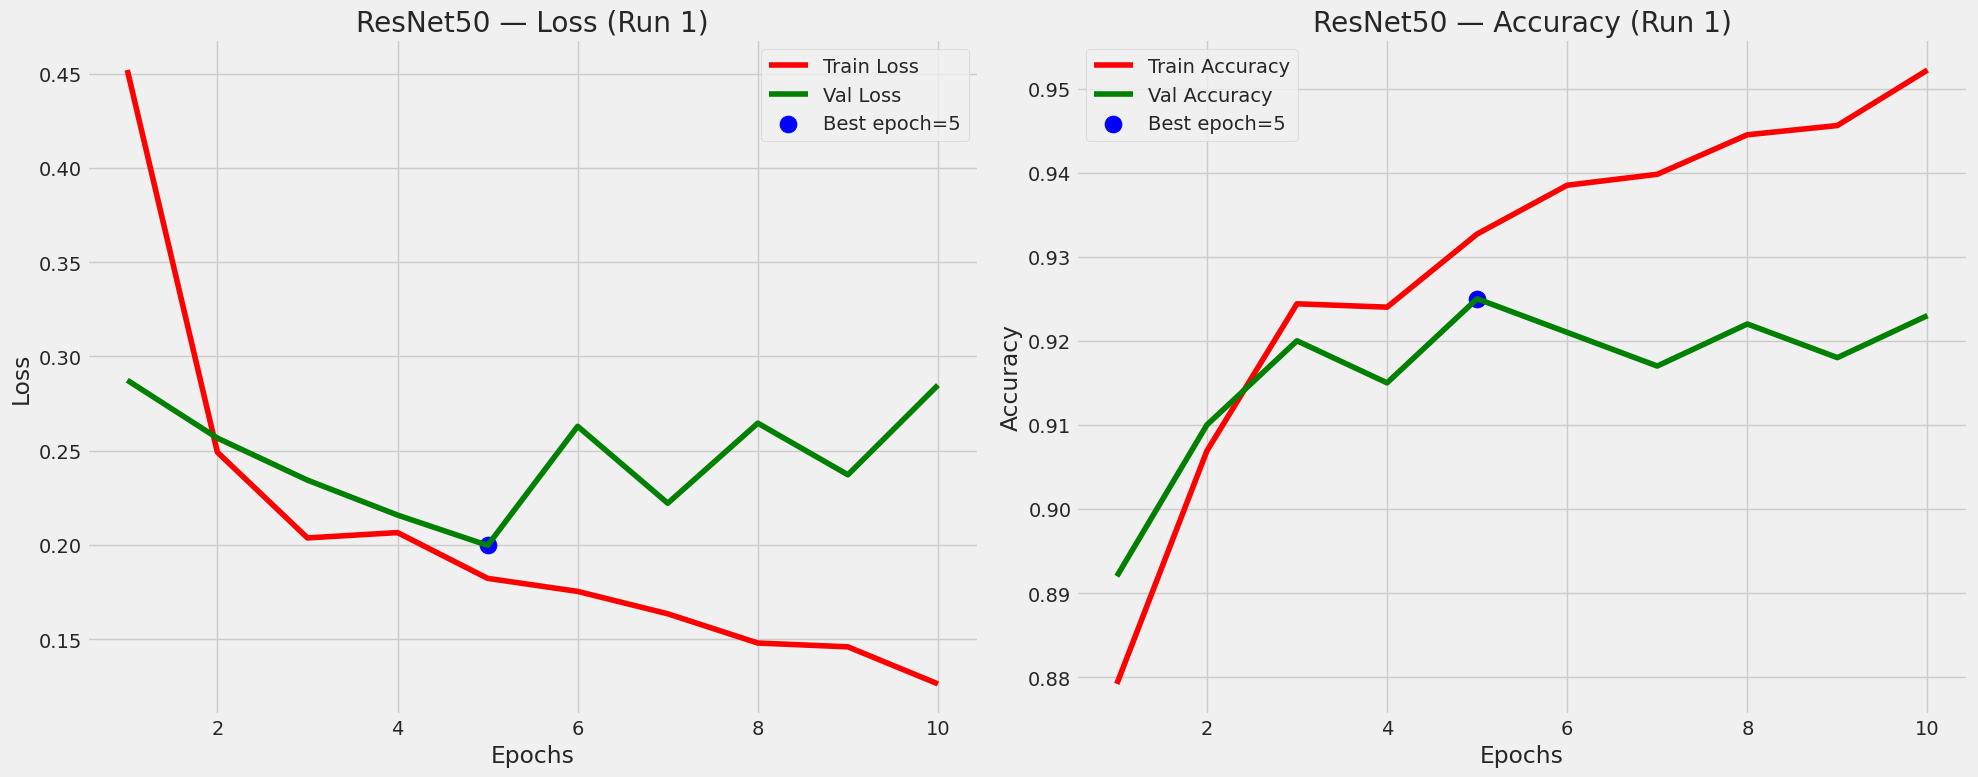

63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step
              precision    recall  f1-score   support

      benign       0.91      0.95      0.93       500
   malignant       0.95      0.90      0.92       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.92      1000
weighted avg       0.93      0.93      0.92      1000

63/63 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9520 - loss: 0.1444


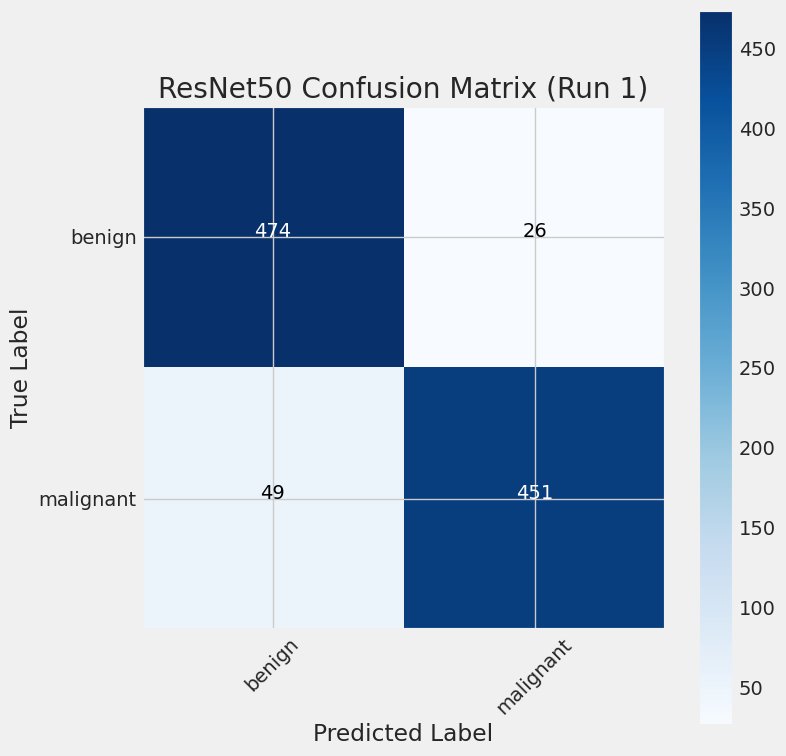

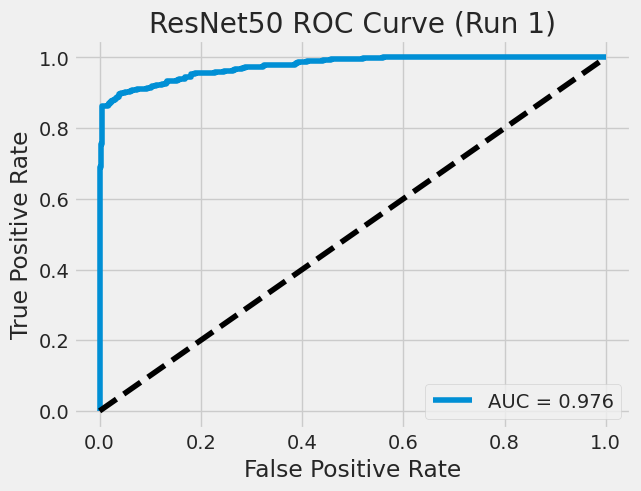


==================================================  ResNet50 Run 1
  test_loss                   : 0.1569
  test_accuracy               : 0.9500
  sensitivity                 : 0.9020
  PPV                         : 0.9455
  NPV                         : 0.9063
  AUC                         : 0.9755
  inference_time              : 0.0757
  f1_benign                   : 0.9267
  f1_malignant                : 0.9232
  precision_benign            : 0.9063
  recall_benign               : 0.9480
  precision_malignant         : 0.9455
  recall_malignant            : 0.9020
ResNet50 model size: 102.70 MB

############################################################
  RUN 2 / 3
############################################################

Found 10000 validated image filenames belonging to 2 classes.
Found 1000 validated image filenames belonging to 2 classes.

--- MobileNetV2 (Run 2) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,920,002 (11.14 MB)

 Trainable params: 659,458 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 226s 353ms/step - accuracy: 0.7842 - loss: 0.6056 - val_accuracy: 0.8700 - val_loss: 0.3275
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 224s 357ms/step - accuracy: 0.8565 - loss: 0.3461 - val_accuracy: 0.8850 - val_loss: 0.3137
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 214s 342ms/step - accuracy: 0.8618 - loss: 0.3400 - val_accuracy: 0.8850 - val_loss: 0.2869
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 278s 368ms/step - accuracy: 0.8770 - loss: 0.2948 - val_accuracy: 0.8830 - val_loss: 0.3284
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 256s 359ms/step - accuracy: 0.8978 - loss: 0.2540 - val_accuracy: 0.8850 - val_loss: 0.3691
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 214s 342ms/step - accuracy: 0.8884 - loss: 0.2858 - val_accuracy: 0.8850 - val_loss: 0.3363
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 225s 360ms/step - accuracy: 0.8991 - loss: 0.2445 - val_accuracy: 0.8960 - val_loss: 0.3153
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 257s 352ms/step - accuracy: 0.9027 - loss: 0.24

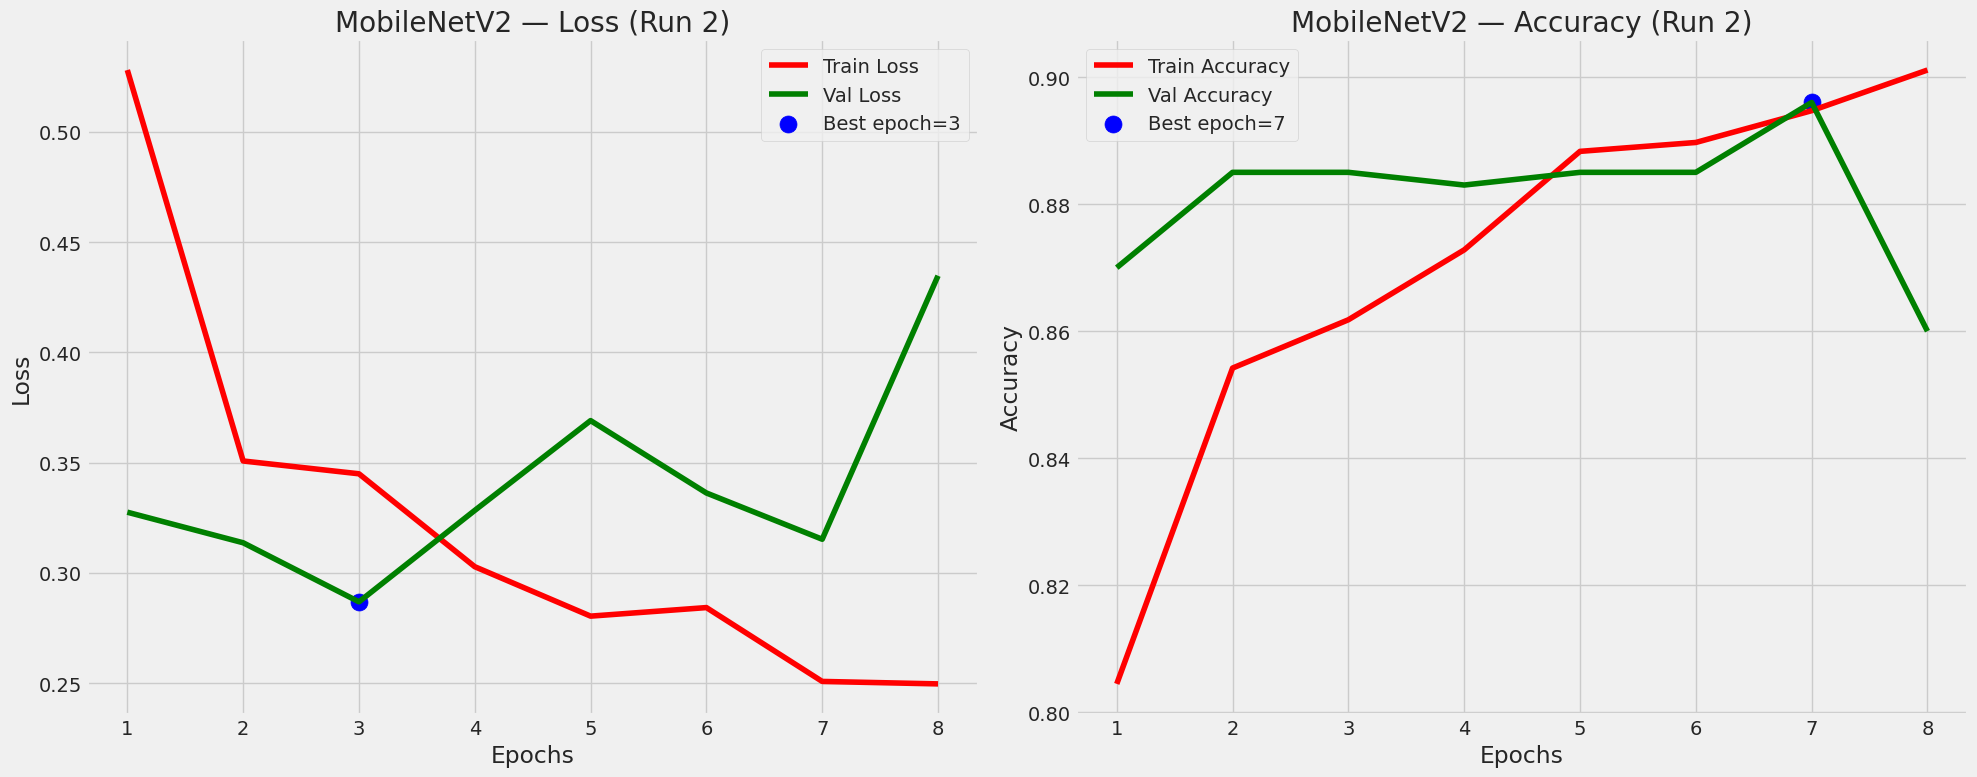

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 336ms/step
              precision    recall  f1-score   support

      benign       0.85      0.93      0.89       500
   malignant       0.92      0.84      0.88       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.88      1000
weighted avg       0.89      0.89      0.88      1000

63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 313ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 316ms/step - accuracy: 0.9286 - loss: 0.2397


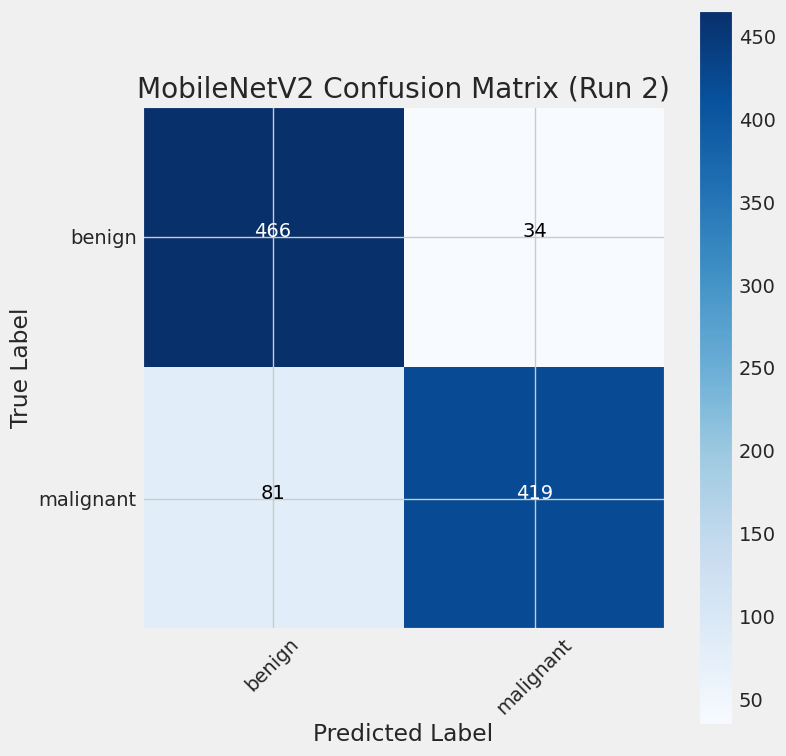

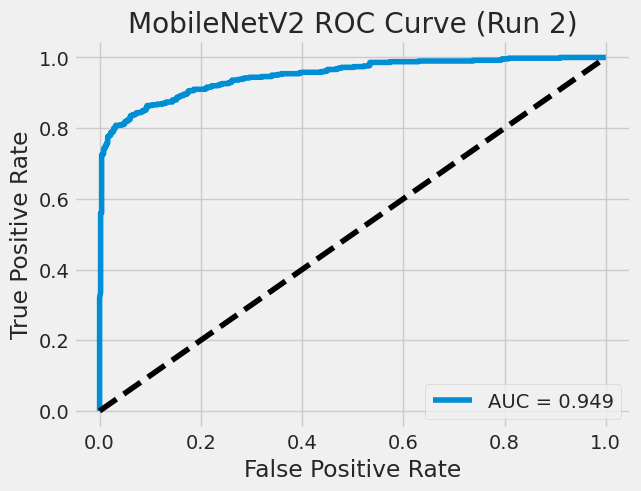


==================================================  MobileNetV2 Run 2
  test_loss                   : 0.2690
  test_accuracy               : 0.9344
  sensitivity                 : 0.8380
  PPV                         : 0.9249
  NPV                         : 0.8519
  AUC                         : 0.9487
  inference_time              : 0.0199
  f1_benign                   : 0.8902
  f1_malignant                : 0.8793
  precision_benign            : 0.8519
  recall_benign               : 0.9320
  precision_malignant         : 0.9249
  recall_malignant            : 0.8380
MobileNetV2 model size: 16.74 MB

--- ResNet50 (Run 2) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,646,018 (94.02 MB)

 Trainable params: 1,054,210 (4.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 853s 1s/step - accuracy: 0.8612 - loss: 0.5860 - val_accuracy: 0.9050 - val_loss: 0.2508
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 840s 1s/step - accuracy: 0.9090 - loss: 0.2399 - val_accuracy: 0.9080 - val_loss: 0.2215
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 840s 1s/step - accuracy: 0.9224 - loss: 0.1950 - val_accuracy: 0.9030 - val_loss: 0.2439
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 845s 1s/step - accuracy: 0.9267 - loss: 0.1923 - val_accuracy: 0.9160 - val_loss: 0.2901
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 850s 1s/step - accuracy: 0.9345 - loss: 0.1817 - val_accuracy: 0.9170 - val_loss: 0.2440
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 845s 1s/step - accuracy: 0.9389 - loss: 0.1627 - val_accuracy: 0.9160 - val_loss: 0.2245
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 858s 1s/step - accuracy: 0.9381 - loss: 0.1669 - val_accuracy: 0.9200 - val_loss: 0.2241

ResNet50 training time: 5930.7s


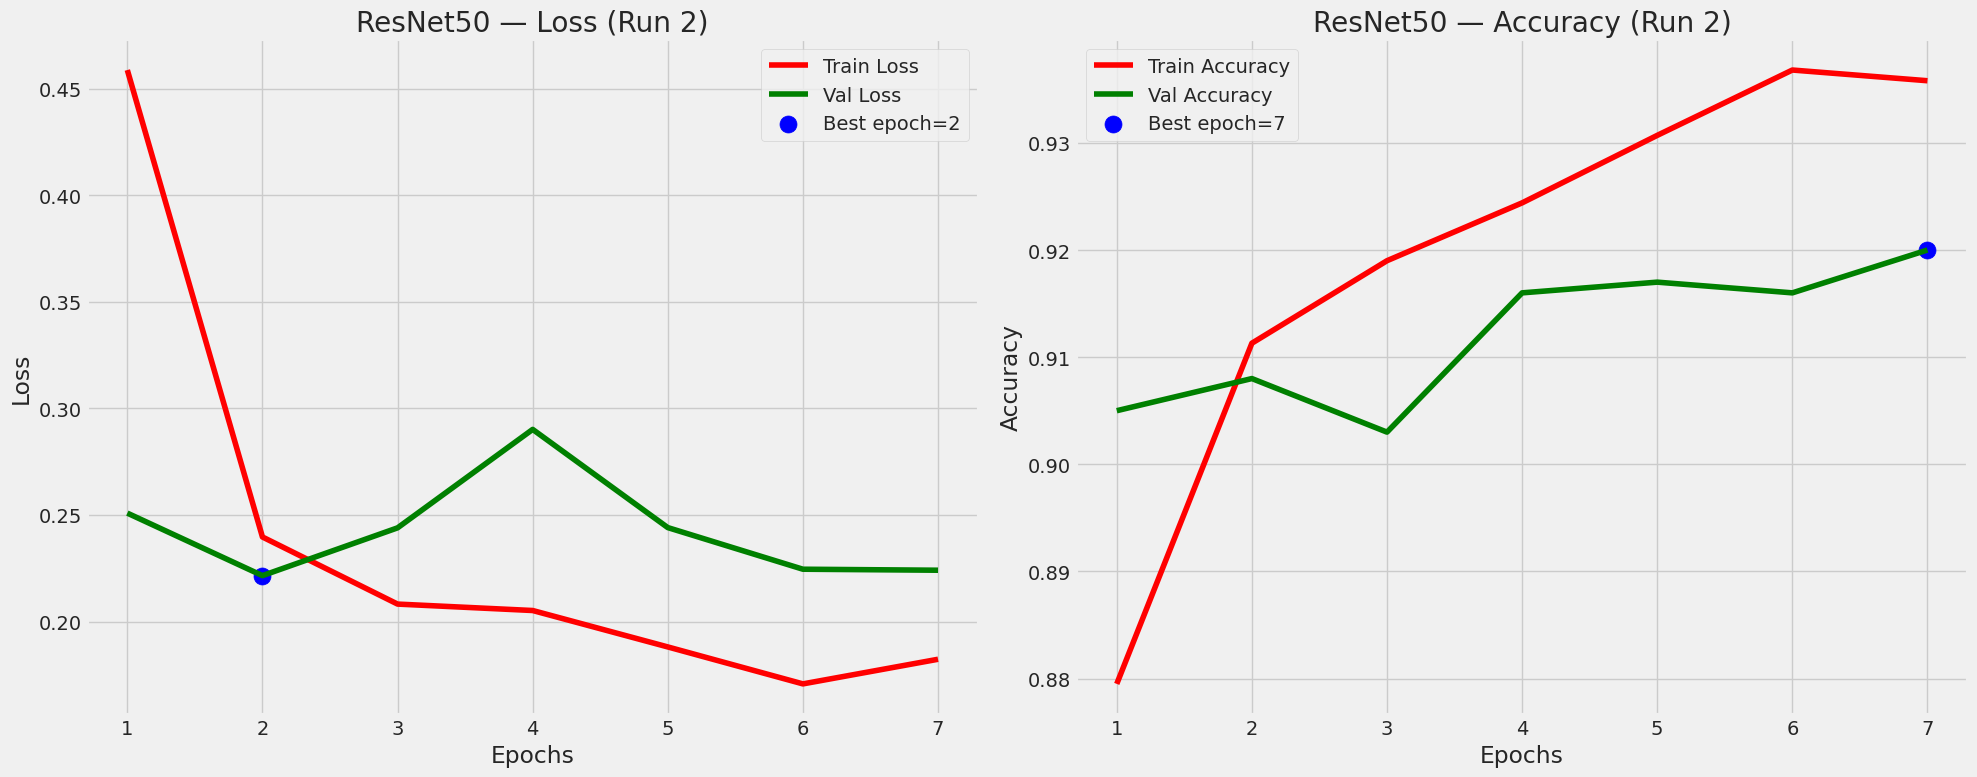

63/63 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step
              precision    recall  f1-score   support

      benign       0.91      0.91      0.91       500
   malignant       0.91      0.91      0.91       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000

63/63 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9146 - loss: 0.2180


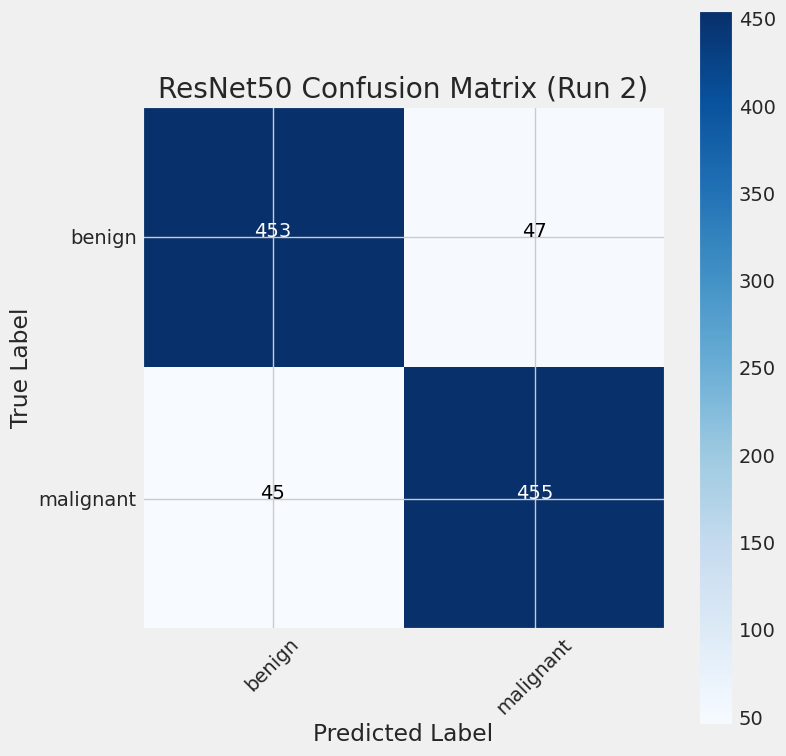

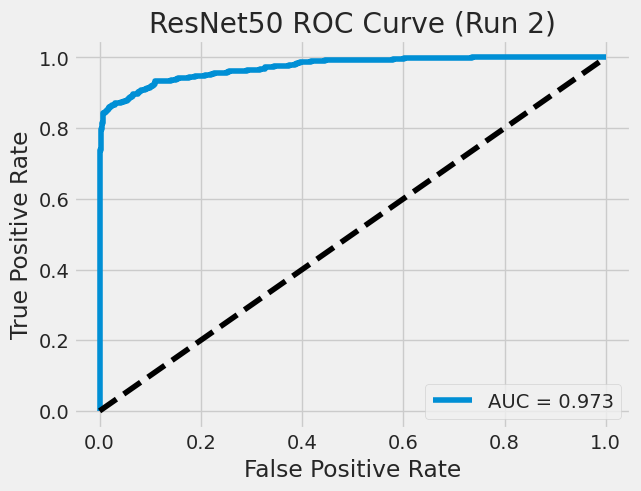


==================================================  ResNet50 Run 2
  test_loss                   : 0.2113
  test_accuracy               : 0.9187
  sensitivity                 : 0.9100
  PPV                         : 0.9064
  NPV                         : 0.9096
  AUC                         : 0.9727
  inference_time              : 0.0760
  f1_benign                   : 0.9078
  f1_malignant                : 0.9082
  precision_benign            : 0.9096
  recall_benign               : 0.9060
  precision_malignant         : 0.9064
  recall_malignant            : 0.9100
ResNet50 model size: 102.70 MB

############################################################
  RUN 3 / 3
############################################################

Found 10000 validated image filenames belonging to 2 classes.
Found 1000 validated image filenames belonging to 2 classes.

--- MobileNetV2 (Run 3) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,920,002 (11.14 MB)

 Trainable params: 659,458 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 225s 351ms/step - accuracy: 0.7868 - loss: 0.6306 - val_accuracy: 0.8850 - val_loss: 0.3549
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 214s 342ms/step - accuracy: 0.8524 - loss: 0.3671 - val_accuracy: 0.8910 - val_loss: 0.3177
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 212s 340ms/step - accuracy: 0.8585 - loss: 0.3260 - val_accuracy: 0.8840 - val_loss: 0.3384
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 217s 346ms/step - accuracy: 0.8716 - loss: 0.3036 - val_accuracy: 0.8790 - val_loss: 0.3130
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 218s 349ms/step - accuracy: 0.8846 - loss: 0.2794 - val_accuracy: 0.8910 - val_loss: 0.3366
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 219s 349ms/step - accuracy: 0.8952 - loss: 0.2644 - val_accuracy: 0.8910 - val_loss: 0.3041
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 354ms/step - accuracy: 0.8936 - loss: 0.2611 - val_accuracy: 0.8880 - val_loss: 0.3392
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 215s 345ms/step - accuracy: 0.9049 - loss: 0.23

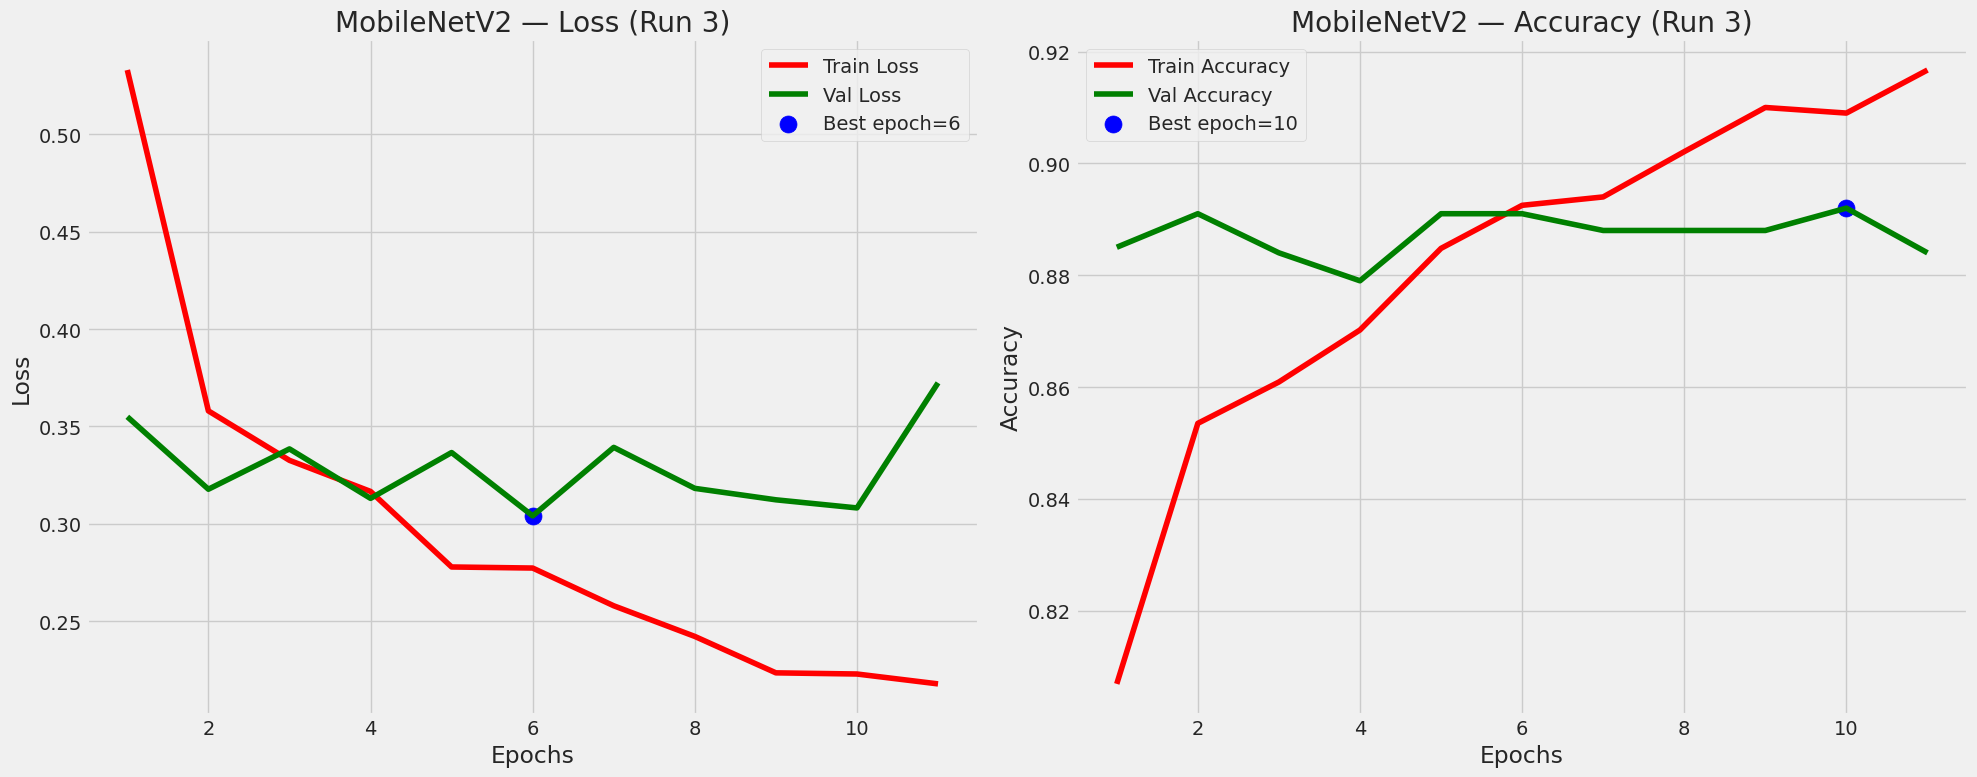

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 333ms/step
              precision    recall  f1-score   support

      benign       0.89      0.90      0.89       500
   malignant       0.90      0.88      0.89       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000

63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 308ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 329ms/step - accuracy: 0.9256 - loss: 0.2536


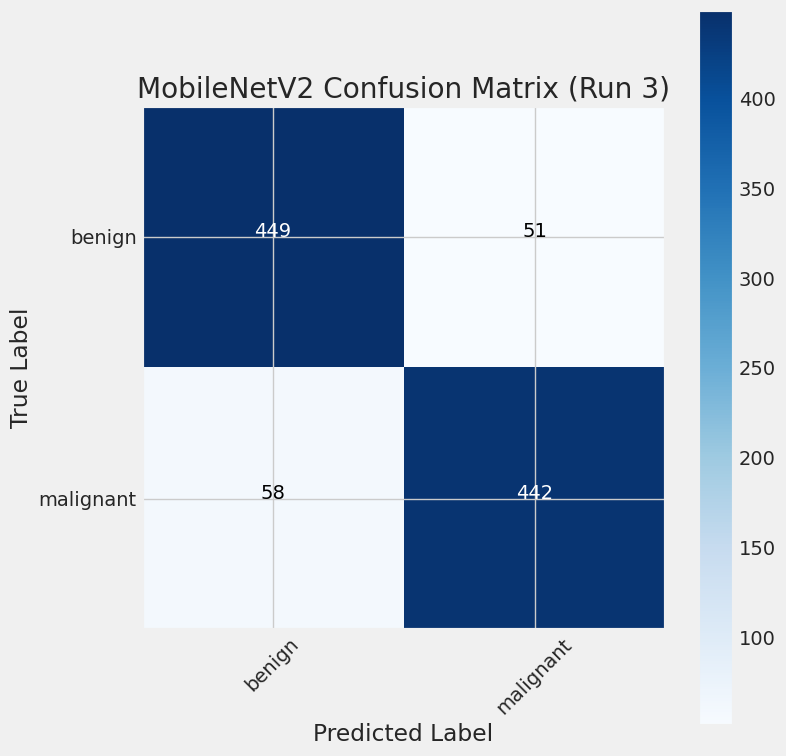

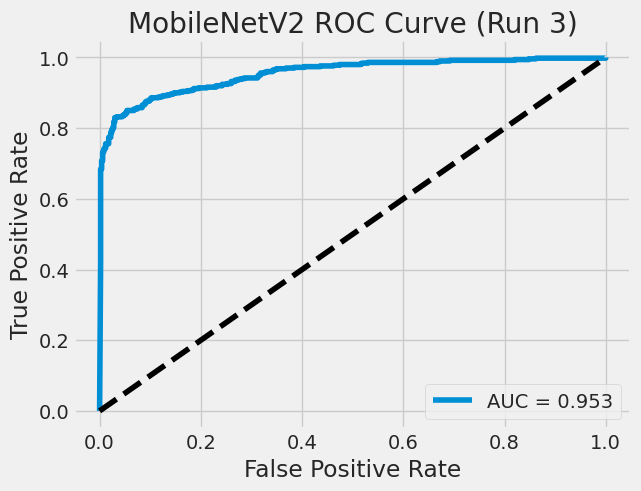


==================================================  MobileNetV2 Run 3
  test_loss                   : 0.3191
  test_accuracy               : 0.9031
  sensitivity                 : 0.8840
  PPV                         : 0.8966
  NPV                         : 0.8856
  AUC                         : 0.9534
  inference_time              : 0.0196
  f1_benign                   : 0.8918
  f1_malignant                : 0.8902
  precision_benign            : 0.8856
  recall_benign               : 0.8980
  precision_malignant         : 0.8966
  recall_malignant            : 0.8840
MobileNetV2 model size: 16.74 MB

--- ResNet50 (Run 3) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,646,018 (94.02 MB)

 Trainable params: 1,054,210 (4.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 855s 1s/step - accuracy: 0.8552 - loss: 0.5965 - val_accuracy: 0.9080 - val_loss: 0.2531
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 851s 1s/step - accuracy: 0.9117 - loss: 0.2463 - val_accuracy: 0.9080 - val_loss: 0.2574
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 848s 1s/step - accuracy: 0.9200 - loss: 0.2135 - val_accuracy: 0.9210 - val_loss: 0.2501
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 847s 1s/step - accuracy: 0.9348 - loss: 0.1856 - val_accuracy: 0.9180 - val_loss: 0.2705
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 852s 1s/step - accuracy: 0.9320 - loss: 0.1906 - val_accuracy: 0.9140 - val_loss: 0.2662
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 847s 1s/step - accuracy: 0.9337 - loss: 0.1755 - val_accuracy: 0.9140 - val_loss: 0.2410
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 845s 1s/step - accuracy: 0.9461 - loss: 0.1500 - val_accuracy: 0.9140 - val_loss: 0.2900
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 864s 1s/step - accuracy: 0.9489 - loss: 0.1361 - val_accu

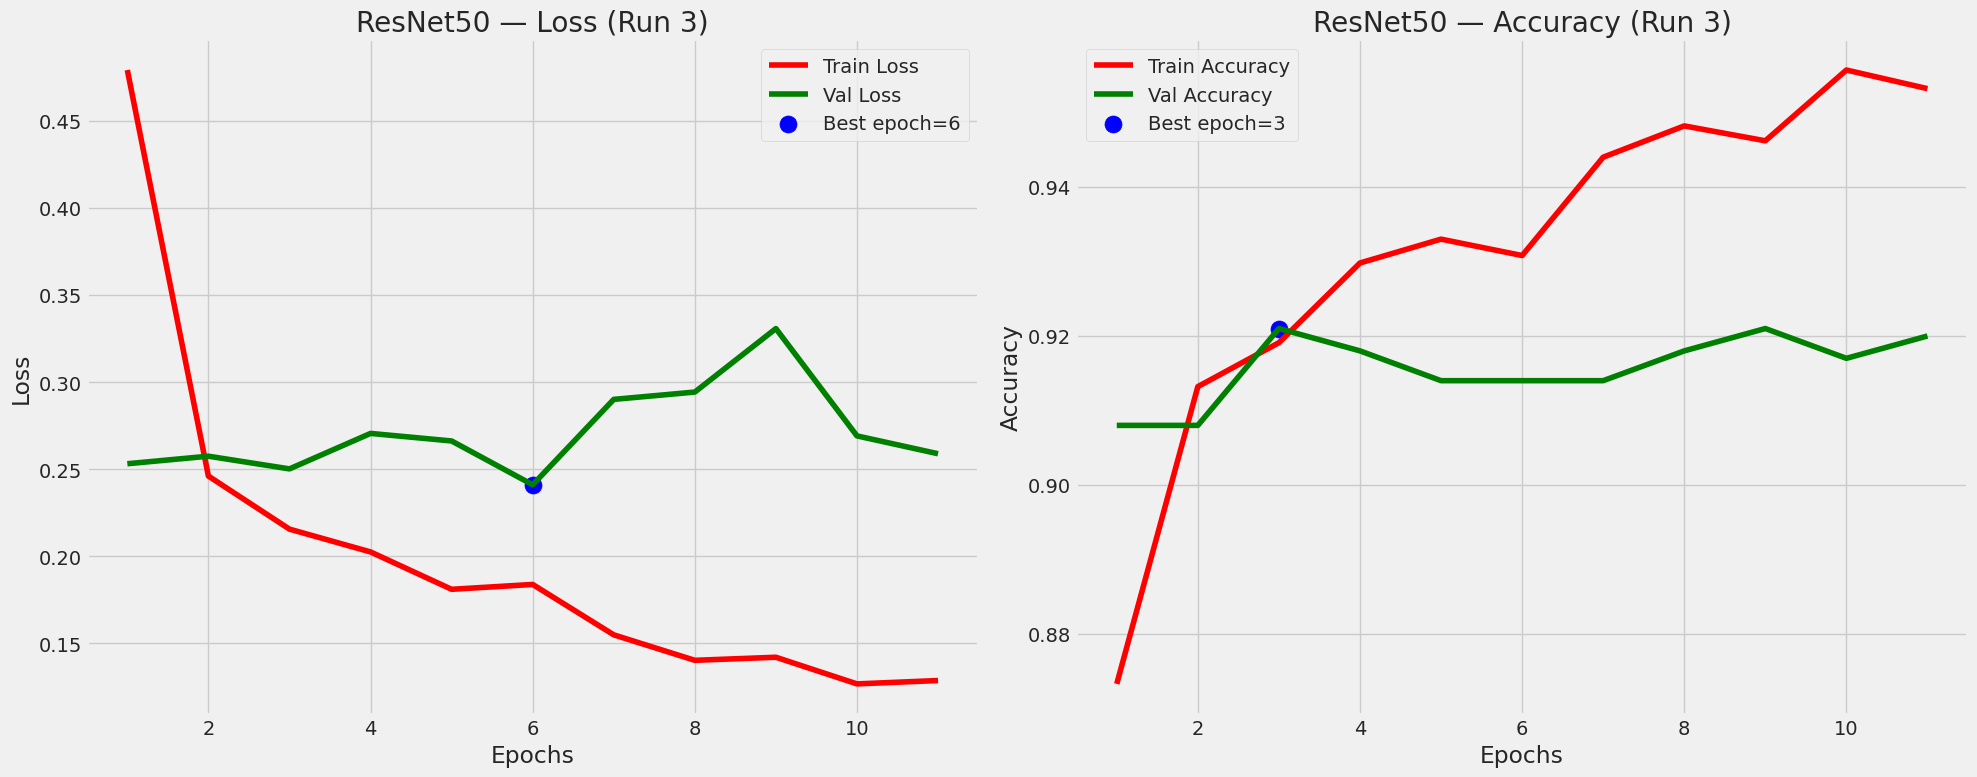

63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step
              precision    recall  f1-score   support

      benign       0.89      0.94      0.92       500
   malignant       0.94      0.88      0.91       500

    accuracy                           0.91      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.91      0.91      1000

63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9405 - loss: 0.2465


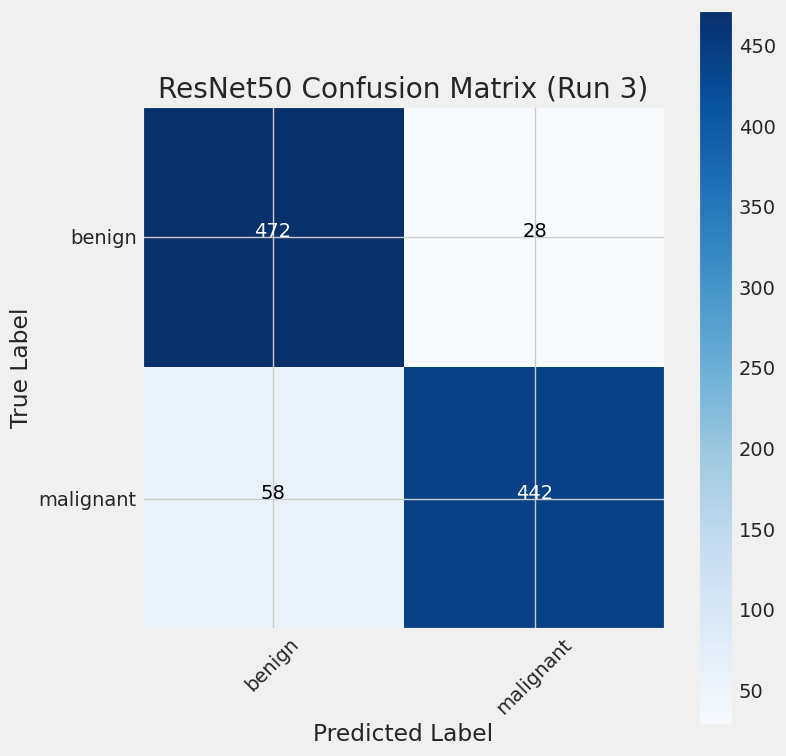

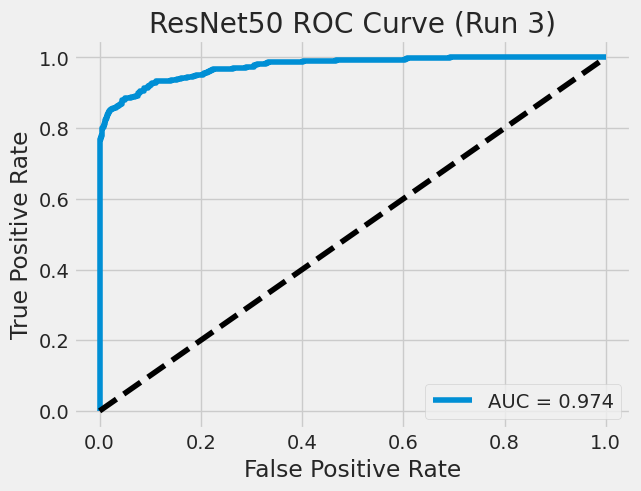


==================================================  ResNet50 Run 3
  test_loss                   : 0.2103
  test_accuracy               : 0.9500
  sensitivity                 : 0.8840
  PPV                         : 0.9404
  NPV                         : 0.8906
  AUC                         : 0.9743
  inference_time              : 0.0772
  f1_benign                   : 0.9165
  f1_malignant                : 0.9113
  precision_benign            : 0.8906
  recall_benign               : 0.9440
  precision_malignant         : 0.9404
  recall_malignant            : 0.8840
ResNet50 model size: 102.70 MB


In [7]:
all_results = {'MobileNetV2': [], 'ResNet50': []}

for run in range(1, N_RUNS + 1):
    print(f"\n{'#'*60}")
    print(f"  RUN {run} / {N_RUNS}")
    print(f"{'#'*60}\n")

    tf.keras.backend.clear_session()
    gc.collect()

    train_gen, test_gen = build_generators(train_df_balanced, test_df)
    classes     = list(train_gen.class_indices.keys())
    class_count = len(classes)
    early_stop  = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # ── MobileNetV2 ───────────────────────────────────────────────────────
    print(f"\n--- MobileNetV2 (Run {run}) ---")
    model_mv2 = build_mobilenetv2(IMG_SHAPE, class_count)
    model_mv2.summary()

    t0 = time.time()
    hist_mv2 = model_mv2.fit(train_gen, epochs=EPOCHS, verbose=1,
                              validation_data=test_gen,
                              callbacks=[early_stop], shuffle=False)
    print(f"\nMobileNetV2 training time: {time.time()-t0:.1f}s")

    plot_history(hist_mv2, 'MobileNetV2', run)
    m1 = evaluate_model(model_mv2, test_gen, classes, 'MobileNetV2', run)

    mv2_path = f'/kaggle/working/mobilenetv2_run{run}.keras'
    model_mv2.save(mv2_path)
    m1['model_size_MB'] = os.path.getsize(mv2_path) / (1024 * 1024)
    print(f"MobileNetV2 model size: {m1['model_size_MB']:.2f} MB")
    all_results['MobileNetV2'].append(m1)

    del model_mv2; gc.collect(); tf.keras.backend.clear_session()

    # ── ResNet50 ──────────────────────────────────────────────────────────
    print(f"\n--- ResNet50 (Run {run}) ---")
    model_rn50 = build_resnet50(IMG_SHAPE, class_count)
    model_rn50.summary()

    t0 = time.time()
    hist_rn50 = model_rn50.fit(train_gen, epochs=EPOCHS, verbose=1,
                                validation_data=test_gen,
                                callbacks=[early_stop], shuffle=False)
    print(f"\nResNet50 training time: {time.time()-t0:.1f}s")

    plot_history(hist_rn50, 'ResNet50', run)
    m2 = evaluate_model(model_rn50, test_gen, classes, 'ResNet50', run)

    rn50_path = f'/kaggle/working/resnet50_run{run}.keras'
    model_rn50.save(rn50_path)
    m2['model_size_MB'] = os.path.getsize(rn50_path) / (1024 * 1024)
    print(f"ResNet50 model size: {m2['model_size_MB']:.2f} MB")
    all_results['ResNet50'].append(m2)

    del model_rn50; gc.collect()

## 8. Mean Results Across All Runs

In [8]:
metric_keys = [
    'test_loss', 'test_accuracy', 'sensitivity', 'PPV', 'NPV',
    'AUC', 'inference_time', 'f1_benign', 'f1_malignant',
    'precision_benign', 'recall_benign', 'precision_malignant',
    'recall_malignant', 'model_size_MB'
]

summary_rows = []
for model_name, runs in all_results.items():
    row = {'Model': model_name}
    for k in metric_keys:
        vals = [r[k] for r in runs if k in r]
        row[f'{k}_mean'] = np.mean(vals)
        row[f'{k}_std']  = np.std(vals)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('/kaggle/working/mean_results_summary.csv', index=False)

print(f"{'='*60}")
print("  MEAN RESULTS ACROSS ALL RUNS")
print(f"{'='*60}")
for row in summary_rows:
    print(f"\n{row['Model']}:")
    for k in metric_keys:
        print(f"  {k:<30}: {row[f'{k}_mean']:.4f} ± {row[f'{k}_std']:.4f}")
print("\nSaved → /kaggle/working/mean_results_summary.csv")

  MEAN RESULTS ACROSS ALL RUNS

MobileNetV2:
  test_loss                     : 0.3094 ± 0.0299
  test_accuracy                 : 0.9062 ± 0.0218
  sensitivity                   : 0.8660 ± 0.0201
  PPV                           : 0.9015 ± 0.0175
  NPV                           : 0.8715 ± 0.0143
  AUC                           : 0.9517 ± 0.0021
  inference_time                : 0.0195 ± 0.0004
  f1_benign                     : 0.8875 ± 0.0050
  f1_malignant                  : 0.8830 ± 0.0051
  precision_benign              : 0.8715 ± 0.0143
  recall_benign                 : 0.9047 ± 0.0202
  precision_malignant           : 0.9015 ± 0.0175
  recall_malignant              : 0.8660 ± 0.0201
  model_size_MB                 : 16.7390 ± 0.0000

ResNet50:
  test_loss                     : 0.1928 ± 0.0254
  test_accuracy                 : 0.9396 ± 0.0147
  sensitivity                   : 0.8987 ± 0.0109
  PPV                           : 0.9308 ± 0.0174
  NPV                           : 0.9022 ± 

## 9. Final Comparison Table

In [9]:
display_metrics = [
    'test_accuracy', 'sensitivity', 'PPV', 'NPV',
    'AUC', 'f1_malignant', 'inference_time', 'model_size_MB'
]

model_names = list(all_results.keys())
table_data  = {}
for k in display_metrics:
    table_data[k] = []
    for mn in model_names:
        row  = next(r for r in summary_rows if r['Model'] == mn)
        table_data[k].append(f"{row[f'{k}_mean']:.4f} ± {row[f'{k}_std']:.4f}")

comparison_df = pd.DataFrame(table_data, index=model_names).T
comparison_df.index.name = 'Metric'
print(comparison_df.to_string())
comparison_df

                     MobileNetV2           ResNet50
Metric                                             
test_accuracy    0.9062 ± 0.0218    0.9396 ± 0.0147
sensitivity      0.8660 ± 0.0201    0.8987 ± 0.0109
PPV              0.9015 ± 0.0175    0.9308 ± 0.0174
NPV              0.8715 ± 0.0143    0.9022 ± 0.0083
AUC              0.9517 ± 0.0021    0.9742 ± 0.0012
f1_malignant     0.8830 ± 0.0051    0.9143 ± 0.0065
inference_time   0.0195 ± 0.0004    0.0763 ± 0.0007
model_size_MB   16.7390 ± 0.0000  102.6959 ± 0.0000


,MobileNetV2,ResNet50
Metric,,
test_accuracy,0.9062 ± 0.0218,0.9396 ± 0.0147
sensitivity,0.8660 ± 0.0201,0.8987 ± 0.0109
PPV,0.9015 ± 0.0175,0.9308 ± 0.0174
NPV,0.8715 ± 0.0143,0.9022 ± 0.0083
AUC,0.9517 ± 0.0021,0.9742 ± 0.0012
f1_malignant,0.8830 ± 0.0051,0.9143 ± 0.0065
inference_time,0.0195 ± 0.0004,0.0763 ± 0.0007
model_size_MB,16.7390 ± 0.0000,102.6959 ± 0.0000
